# 03 - Explorative Datenanalyse: Finanznachrichten (EODHD News API)

**Ziel:** Finanznachrichten zu unseren Währungspaaren laden, erkunden und Sentiment-Daten analysieren.

**Datenquelle:** EODHD News API + Sentiment API

**APIs:**
- News API: `https://eodhd.com/api/news?s=EURUSD.FOREX&fmt=json`
- Sentiment API: `https://eodhd.com/api/sentiments?s=EURUSD.FOREX&fmt=json`

**Hinweis:** Jeder News-Request verbraucht 5 API-Calls. Free Plan = 20 Calls/Tag.

---

## 1. Setup und Imports

In [6]:
# Bibliotheken importieren
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pathlib
import json
from dotenv import load_dotenv

# Darstellung konfigurieren
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

print('Setup erfolgreich!')

Setup erfolgreich!


## 2. API-Key laden

In [7]:
# .env Datei laden
for env_path in ['../.env', '.env', str(pathlib.Path.home() / 'Documents/GitHub/datawrangling/.env')]:
    if os.path.exists(env_path):
        load_dotenv(dotenv_path=env_path, override=True)
        print(f'.env gefunden unter: {env_path}')
        break

api_key = os.getenv('EODHD_API_KEY')

if api_key and api_key != 'dein_api_key_hier':
    print(f'API-Key geladen (beginnt mit: {api_key[:4]}...)')
else:
    print('FEHLER: Kein API-Key gefunden!')

.env gefunden unter: /Users/jeremynathan/Documents/GitHub/datawrangling/.env
API-Key geladen (beginnt mit: 6917...)


## 3. Finanznachrichten laden (News API)

Die News API liefert Artikel mit Titel, Inhalt, Tags und **Sentiment-Scores** (polarity, pos, neg, neu).

**Achtung:** Jeder Request verbraucht 5 API-Calls. Wir laden daher erstmal nur für ein Währungspaar.

In [8]:
# Konfiguration
CURRENCY_PAIRS = {
    'EURUSD.FOREX': 'EUR/USD',
    'EURCHF.FOREX': 'EUR/CHF',
    'GBPUSD.FOREX': 'GBP/USD',
}

START_DATE = '2022-01-01'
END_DATE = '2026-03-25'

print(f'Zeitraum: {START_DATE} bis {END_DATE}')
print(f'Währungspaare: {list(CURRENCY_PAIRS.values())}')
print(f'\nHinweis: Jeder Request = 5 API-Calls (Free Plan = 20/Tag)')

Zeitraum: 2022-01-01 bis 2026-03-25
Währungspaare: ['EUR/USD', 'EUR/CHF', 'GBP/USD']

Hinweis: Jeder Request = 5 API-Calls (Free Plan = 20/Tag)


In [9]:
def load_news(ticker, start_date, end_date, api_key, limit=300):
    """
    Lädt Finanznachrichten von der EODHD News API.
    Pagination: Die API liefert max. 1000 Artikel pro Request.
    Wir laden in Schritten von 'limit' Artikeln.
    """
    all_articles = []
    offset = 0
    
    while True:
        url = 'https://eodhd.com/api/news'
        params = {
            's': ticker,
            'from': start_date,
            'to': end_date,
            'limit': limit,
            'offset': offset,
            'api_token': api_key,
            'fmt': 'json'
        }
        
        response = requests.get(url, params=params)
        
        if response.status_code != 200:
            print(f'  FEHLER: HTTP {response.status_code}')
            break
        
        articles = response.json()
        
        if not articles:
            break
        
        all_articles.extend(articles)
        print(f'  Offset {offset}: {len(articles)} Artikel geladen')
        
        # Wenn weniger als limit zurückkommen, sind wir fertig
        if len(articles) < limit:
            break
        
        offset += limit
    
    return all_articles

print('Funktion definiert.')

Funktion definiert.


In [10]:
# Nachrichten für alle Währungspaare laden
news_raw = {}   # Rohdaten (API-Response als Liste von Dicts)
news_data = {}  # Verarbeitete DataFrames

for eodhd_symbol, pair_name in CURRENCY_PAIRS.items():
    print(f'\nLade Nachrichten für {pair_name} ({eodhd_symbol})...')
    
    articles = load_news(eodhd_symbol, START_DATE, END_DATE, api_key)
    
    if articles:
        # Rohdaten merken (für JSON-Speicherung)
        news_raw[pair_name] = articles
        
        # Verarbeitung: DataFrame erstellen
        df = pd.DataFrame(articles)
        df['date'] = pd.to_datetime(df['date'])
        df['date_only'] = df['date'].dt.date
        
        # Sentiment-Spalten extrahieren (None bleibt als NaN erhalten!)
        if 'sentiment' in df.columns:
            sentiment_df = df['sentiment'].apply(
                lambda x: pd.Series(x) if isinstance(x, dict) else pd.Series(dtype=float)
            )
            df = pd.concat([df.drop(columns=['sentiment']), sentiment_df], axis=1)
        
        news_data[pair_name] = df
        print(f'  Gesamt: {len(df)} Artikel geladen')
        
        # Fehlende Sentiments zaehlen
        if 'polarity' in df.columns:
            missing = df['polarity'].isna().sum()
            print(f'  Davon ohne Sentiment: {missing} ({missing/len(df)*100:.1f}%)')
    else:
        print(f'  Keine Artikel gefunden.')

print('\nAlle Nachrichten geladen!')


Lade Nachrichten für EUR/USD (EURUSD.FOREX)...
  Offset 0: 300 Artikel geladen
  Offset 300: 300 Artikel geladen
  Offset 600: 300 Artikel geladen
  Offset 900: 300 Artikel geladen
  Offset 1200: 300 Artikel geladen
  Offset 1500: 300 Artikel geladen
  Offset 1800: 300 Artikel geladen
  Offset 2100: 300 Artikel geladen
  Offset 2400: 300 Artikel geladen
  Offset 2700: 300 Artikel geladen
  Offset 3000: 300 Artikel geladen
  Offset 3300: 300 Artikel geladen
  Offset 3600: 300 Artikel geladen
  Offset 3900: 300 Artikel geladen
  Offset 4200: 300 Artikel geladen
  Offset 4500: 300 Artikel geladen
  Offset 4800: 300 Artikel geladen
  Offset 5100: 300 Artikel geladen
  Offset 5400: 300 Artikel geladen
  Offset 5700: 300 Artikel geladen
  Offset 6000: 300 Artikel geladen
  Offset 6300: 300 Artikel geladen
  Offset 6600: 300 Artikel geladen
  Offset 6900: 300 Artikel geladen
  Offset 7200: 300 Artikel geladen
  Offset 7500: 300 Artikel geladen
  Offset 7800: 300 Artikel geladen
  Offset 8100

## 4. Erste Datenübersicht

In [11]:
# Übersicht
for pair_name, df in news_data.items():
    print(f'\n{"=" * 60}')
    print(f'{pair_name}')
    print(f'{"=" * 60}')
    print(f'Anzahl Artikel: {len(df)}')
    print(f'Zeitraum: {df["date"].min()} bis {df["date"].max()}')
    print(f'Spalten: {list(df.columns)}')
    print(f'\nDatentypen:')
    print(df.dtypes)
    print(f'\nErste 3 Artikel (Titel):')
    for i, row in df.head(3).iterrows():
        print(f'  [{row["date"].strftime("%Y-%m-%d")}] {row["title"][:80]}...')


EUR/USD
Anzahl Artikel: 27758
Zeitraum: 2022-01-01 03:19:07+00:00 bis 2026-03-25 07:23:17+00:00
Spalten: ['date', 'title', 'content', 'link', 'symbols', 'tags', 'date_only', 'polarity', 'neg', 'neu', 'pos']

Datentypen:
date         datetime64[us, UTC]
title                        str
content                      str
link                         str
symbols                   object
tags                      object
date_only                 object
polarity                 float64
neg                      float64
neu                      float64
pos                      float64
dtype: object

Erste 3 Artikel (Titel):
  [2026-03-25] When is the IFO German Survey and how could it affect EUR/USD?...
  [2026-03-25] EUR/USD: Range trading holds near 1.16 – Danske Bank...
  [2026-03-25] EUR/CHF: SNB threat seen as limited deterrent – Commerzbank...

EUR/CHF
Anzahl Artikel: 13
Zeitraum: 2022-07-19 02:54:25+00:00 bis 2025-09-25 08:28:12+00:00
Spalten: ['date', 'title', 'content', 'link', 'symbo

## 5. Datenqualitaetspruefung

In [12]:
# Fehlende Werte und Sentiment-Statistiken
for pair_name, df in news_data.items():
    print(f'\n{"=" * 60}')
    print(f'{pair_name} - Datenqualitaet')
    print(f'{"=" * 60}')
    
    # Fehlende Werte
    missing = df.isnull().sum()
    print(f'\nFehlende Werte:')
    for col in df.columns:
        if missing[col] > 0:
            print(f'  {col}: {missing[col]} ({missing[col]/len(df)*100:.1f}%)')
    if missing.sum() == 0:
        print('  Keine fehlenden Werte!')
    
    # Sentiment-Statistiken
    if 'polarity' in df.columns:
        print(f'\nSentiment-Statistiken (polarity):')
        print(f'  Mittelwert: {df["polarity"].mean():.4f}')
        print(f'  Median:     {df["polarity"].median():.4f}')
        print(f'  Std:        {df["polarity"].std():.4f}')
        print(f'  Min:        {df["polarity"].min():.4f}')
        print(f'  Max:        {df["polarity"].max():.4f}')


EUR/USD - Datenqualitaet

Fehlende Werte:
  polarity: 108 (0.4%)
  neg: 108 (0.4%)
  neu: 108 (0.4%)
  pos: 108 (0.4%)

Sentiment-Statistiken (polarity):
  Mittelwert: 0.0346
  Median:     0.0000
  Std:        0.4159
  Min:        -0.9990
  Max:        1.0000

EUR/CHF - Datenqualitaet

Fehlende Werte:
  polarity: 1 (7.7%)
  neg: 1 (7.7%)
  neu: 1 (7.7%)
  pos: 1 (7.7%)

Sentiment-Statistiken (polarity):
  Mittelwert: 0.2512
  Median:     0.4915
  Std:        0.7006
  Min:        -0.9750
  Max:        0.9970

GBP/USD - Datenqualitaet

Fehlende Werte:
  polarity: 128 (0.7%)
  neg: 128 (0.7%)
  neu: 128 (0.7%)
  pos: 128 (0.7%)

Sentiment-Statistiken (polarity):
  Mittelwert: 0.0478
  Median:     0.0000
  Std:        0.4315
  Min:        -0.9990
  Max:        1.0000


In [13]:
# Artikel pro Tag zaehlen
for pair_name, df in news_data.items():
    print(f'\n{pair_name}:')
    daily_count = df.groupby('date_only').size()
    print(f'  Durchschnitt Artikel/Tag: {daily_count.mean():.1f}')
    print(f'  Max Artikel/Tag:          {daily_count.max()}')
    print(f'  Min Artikel/Tag:          {daily_count.min()}')
    print(f'  Tage mit Artikeln:        {len(daily_count)}')


EUR/USD:
  Durchschnitt Artikel/Tag: 19.6
  Max Artikel/Tag:          61
  Min Artikel/Tag:          1
  Tage mit Artikeln:        1419

EUR/CHF:
  Durchschnitt Artikel/Tag: 1.2
  Max Artikel/Tag:          3
  Min Artikel/Tag:          1
  Tage mit Artikeln:        11

GBP/USD:
  Durchschnitt Artikel/Tag: 12.9
  Max Artikel/Tag:          39
  Min Artikel/Tag:          1
  Tage mit Artikeln:        1391


## 6. Visualisierung

### 6.1 Artikel pro Tag

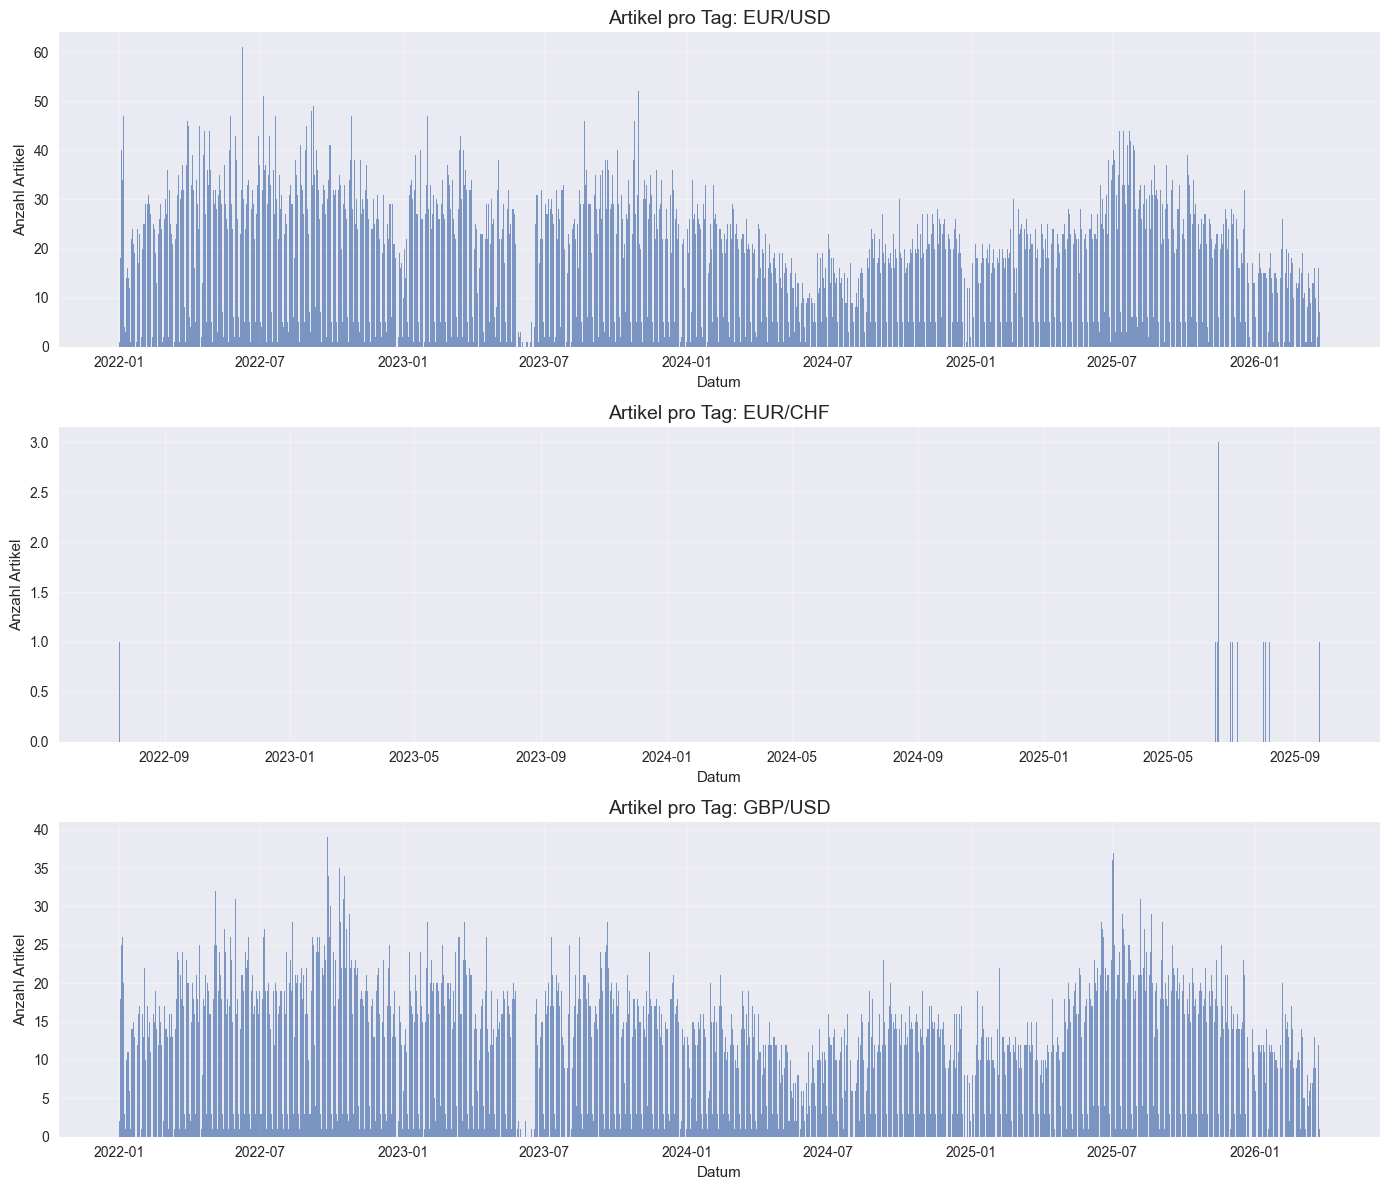

In [14]:
# Artikel pro Tag plotten
fig, axes = plt.subplots(len(news_data), 1, figsize=(14, 4 * len(news_data)))

if len(news_data) == 1:
    axes = [axes]

for ax, (pair_name, df) in zip(axes, news_data.items()):
    daily_count = df.groupby('date_only').size()
    ax.bar(daily_count.index, daily_count.values, alpha=0.7, width=1)
    ax.set_title(f'Artikel pro Tag: {pair_name}', fontsize=14)
    ax.set_xlabel('Datum')
    ax.set_ylabel('Anzahl Artikel')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Sentiment-Verteilung

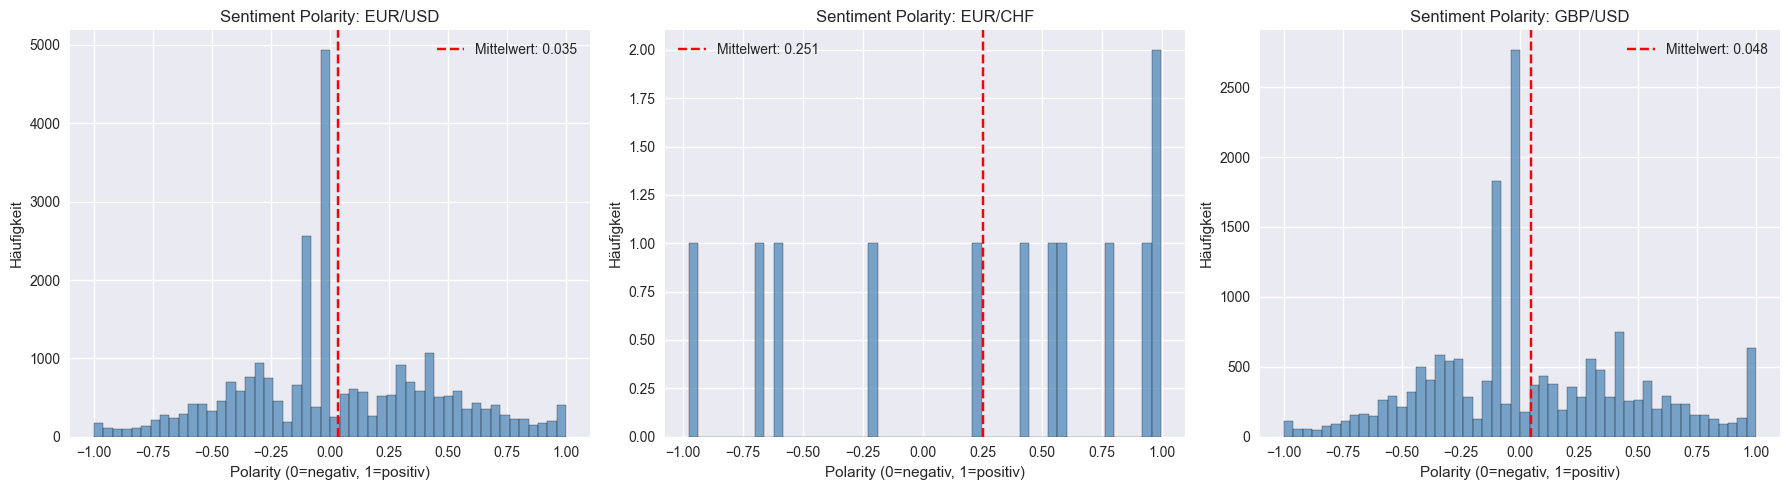

In [15]:
# Sentiment-Verteilung (Polarity)
fig, axes = plt.subplots(1, len(news_data), figsize=(6 * len(news_data), 5))

if len(news_data) == 1:
    axes = [axes]

for ax, (pair_name, df) in zip(axes, news_data.items()):
    if 'polarity' in df.columns:
        ax.hist(df['polarity'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        ax.set_title(f'Sentiment Polarity: {pair_name}', fontsize=12)
        ax.set_xlabel('Polarity (0=negativ, 1=positiv)')
        ax.set_ylabel('Häufigkeit')
        ax.axvline(x=df['polarity'].mean(), color='red', linestyle='--', label=f'Mittelwert: {df["polarity"].mean():.3f}')
        ax.legend()

plt.tight_layout()
plt.show()

### 6.3 Durchschnittliches Sentiment pro Tag

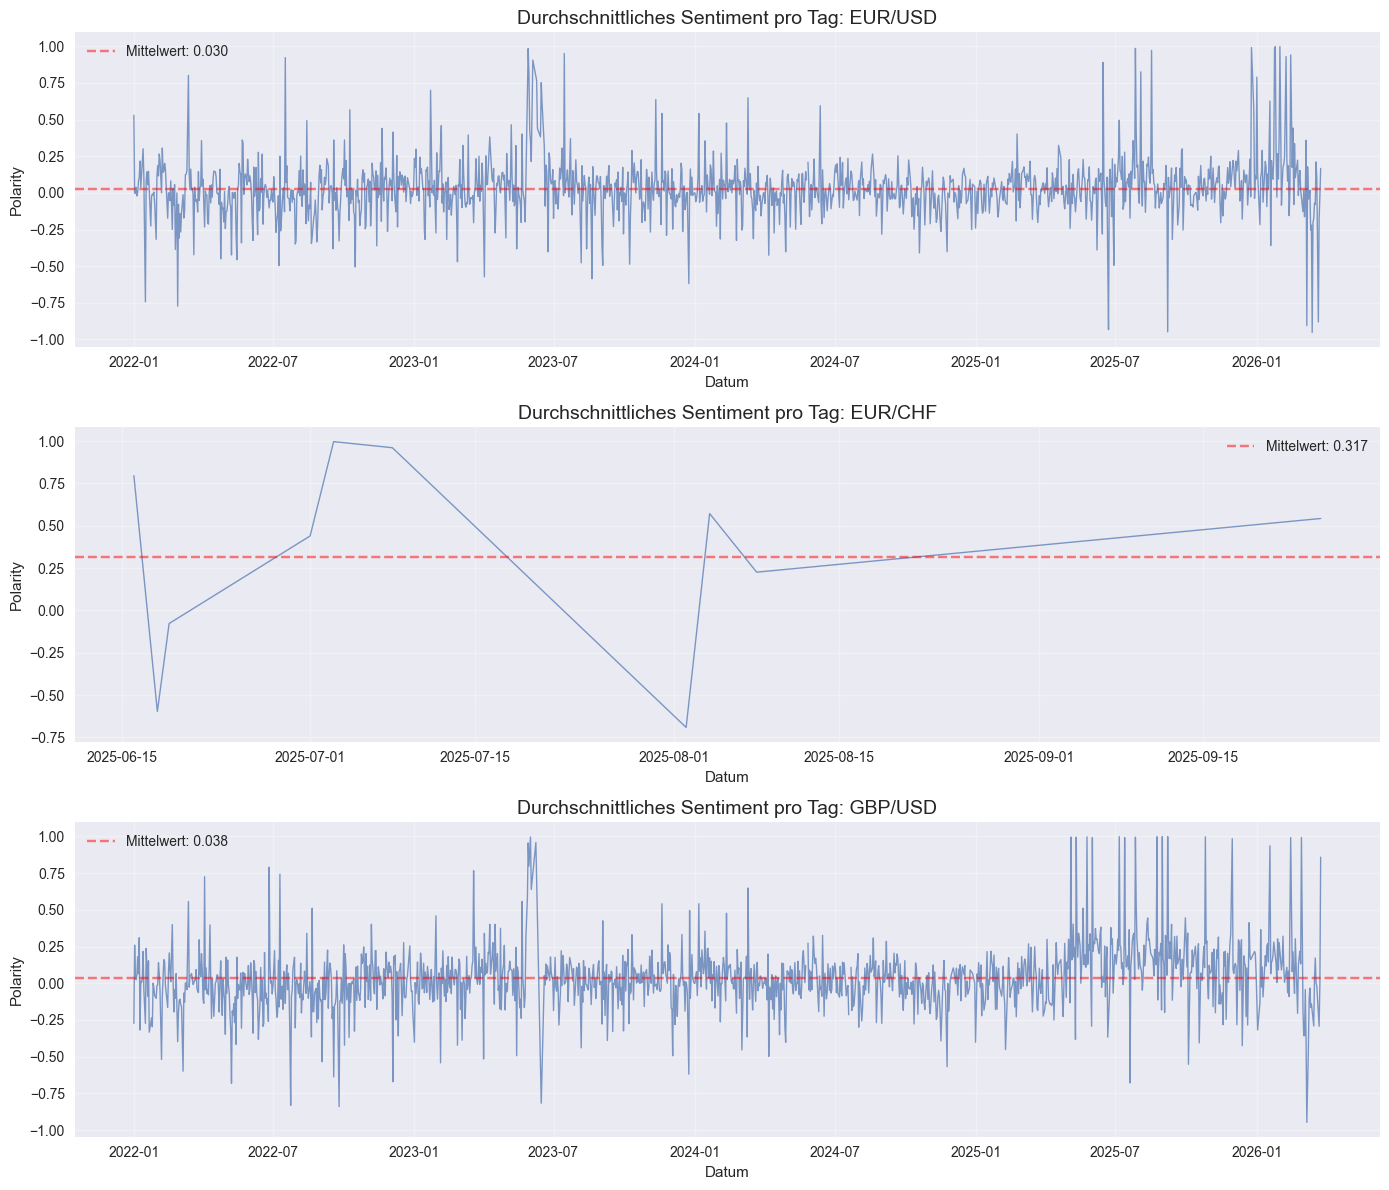

In [16]:
# Durchschnittliches tägliches Sentiment
fig, axes = plt.subplots(len(news_data), 1, figsize=(14, 4 * len(news_data)))

if len(news_data) == 1:
    axes = [axes]

for ax, (pair_name, df) in zip(axes, news_data.items()):
    if 'polarity' in df.columns:
        daily_sentiment = df.groupby('date_only')['polarity'].mean()
        ax.plot(daily_sentiment.index, daily_sentiment.values, linewidth=1, alpha=0.7)
        ax.axhline(y=daily_sentiment.mean(), color='red', linestyle='--', alpha=0.5, label=f'Mittelwert: {daily_sentiment.mean():.3f}')
        ax.set_title(f'Durchschnittliches Sentiment pro Tag: {pair_name}', fontsize=14)
        ax.set_xlabel('Datum')
        ax.set_ylabel('Polarity')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.4 Sentiment-Aufteilung (positiv, negativ, neutral)


EUR/USD - Sentiment-Aufteilung (Durchschnitt):
  Positiv:  0.0621
  Negativ:  0.0625
  Neutral:  0.8691


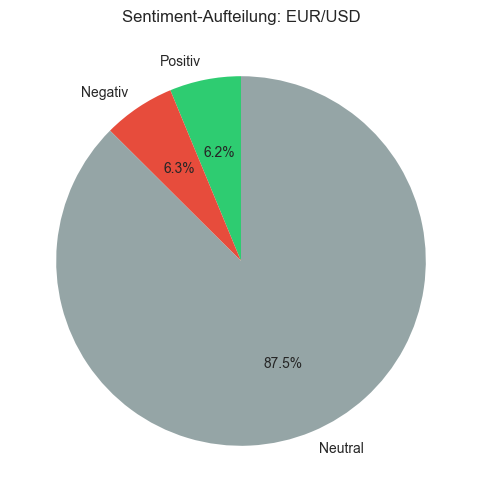


EUR/CHF - Sentiment-Aufteilung (Durchschnitt):
  Positiv:  0.0889
  Negativ:  0.0633
  Neutral:  0.8478


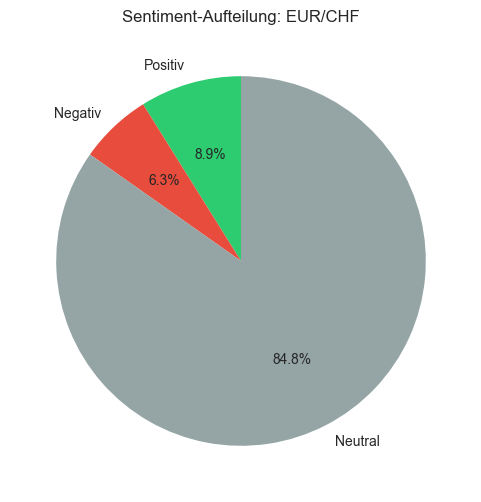


GBP/USD - Sentiment-Aufteilung (Durchschnitt):
  Positiv:  0.0629
  Negativ:  0.0644
  Neutral:  0.8650


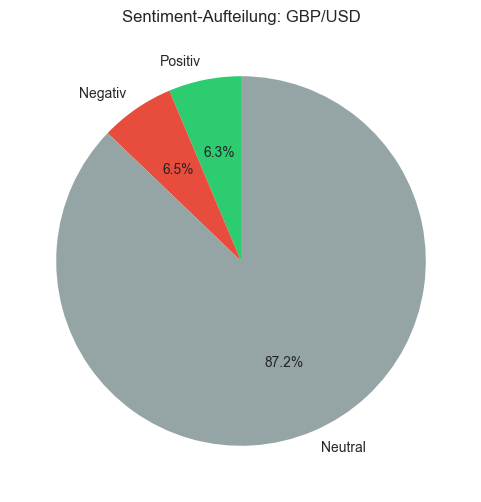

In [17]:
# Sentiment-Komponenten vergleichen
for pair_name, df in news_data.items():
    if all(col in df.columns for col in ['pos', 'neg', 'neu']):
        print(f'\n{pair_name} - Sentiment-Aufteilung (Durchschnitt):')
        print(f'  Positiv:  {df["pos"].mean():.4f}')
        print(f'  Negativ:  {df["neg"].mean():.4f}')
        print(f'  Neutral:  {df["neu"].mean():.4f}')
        
        # Pie Chart
        fig, ax = plt.subplots(figsize=(6, 6))
        values = [df['pos'].mean(), df['neg'].mean(), df['neu'].mean()]
        labels = ['Positiv', 'Negativ', 'Neutral']
        colors = ['#2ecc71', '#e74c3c', '#95a5a6']
        ax.pie(values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
        ax.set_title(f'Sentiment-Aufteilung: {pair_name}')
        plt.show()

## 7. Rohdaten speichern

In [18]:
# Rohdaten speichern
OUTPUT_DIR = '../../data/raw/news/eodhd'
os.makedirs(OUTPUT_DIR, exist_ok=True)

for pair_name in news_data:
    safe_name = pair_name.replace('/', '_')
    
    # 1. Rohdaten als JSON speichern (unveränderte API-Response)
    if pair_name in news_raw:
        json_filename = f'{safe_name}_news_{START_DATE}_to_{END_DATE}.json'
        json_path = os.path.join(OUTPUT_DIR, json_filename)
        with open(json_path, 'w', encoding='utf-8') as f:
            json.dump(news_raw[pair_name], f, ensure_ascii=False, indent=2)
        print(f'JSON gespeichert: {json_path} ({len(news_raw[pair_name])} Artikel)')
    
    # 2. Verarbeitete Daten als CSV speichern
    df = news_data[pair_name].copy()
    
    # Zeilenumbrüche in Textfeldern entfernen (CSV-Lesbarkeit)
    for col in ['title', 'content']:
        if col in df.columns:
            df[col] = df[col].str.replace(r'\s+', ' ', regex=True).str.strip()
    
    csv_filename = f'{safe_name}_news_{START_DATE}_to_{END_DATE}.csv'
    csv_path = os.path.join(OUTPUT_DIR, csv_filename)
    df.to_csv(csv_path, index=False)
    print(f'CSV gespeichert:  {csv_path} ({len(df)} Artikel)')

print('\nAlle Nachrichten-Rohdaten gespeichert!')

JSON gespeichert: ../../data/raw/news/eodhd/EUR_USD_news_2022-01-01_to_2026-03-25.json (27758 Artikel)
CSV gespeichert:  ../../data/raw/news/eodhd/EUR_USD_news_2022-01-01_to_2026-03-25.csv (27758 Artikel)
JSON gespeichert: ../../data/raw/news/eodhd/EUR_CHF_news_2022-01-01_to_2026-03-25.json (13 Artikel)
CSV gespeichert:  ../../data/raw/news/eodhd/EUR_CHF_news_2022-01-01_to_2026-03-25.csv (13 Artikel)
JSON gespeichert: ../../data/raw/news/eodhd/GBP_USD_news_2022-01-01_to_2026-03-25.json (17986 Artikel)
CSV gespeichert:  ../../data/raw/news/eodhd/GBP_USD_news_2022-01-01_to_2026-03-25.csv (17986 Artikel)

Alle Nachrichten-Rohdaten gespeichert!


## 8. Zusammenfassung

### Erkenntnisse:
- **Anzahl Artikel:** (Ergebnisse eintragen)
- **Sentiment-Verteilung:** (Ergebnisse eintragen)
- **Datenqualitaet:** (Ergebnisse eintragen)
- **Zeitliche Abdeckung:** (Ergebnisse eintragen)

### Nächste Schritte:
1. Zweite Nachrichtenquelle laden (Web Scraping)
2. Sentiment-Analyse mit VADER/FinBERT auf Nachrichtentexte anwenden
3. Sentiment mit Forex-Kursen zusammenführen
4. Korrelationsanalyse: Beeinflusst Nachrichtenstimmung die Kurse?